# Stage A — Distributional coverage of collocated AERONET pairs

Training pairs in `/home/slow_data/Air_Quality/Stage_A/collocated/*.csv` are the input
to the CDF bias-correction step (Step A2).  If they do not span the AOD range or density
of the AERONET observations the model will encounter in production, the CDF transfer
function is fit on a non-representative sample and will distort tails when applied to
the full grid.

Coverage has two components and **both** must hold:
1. **Range coverage** — matched pairs span the AOD values present in the full AERONET
   record at the same site over the training period.
2. **Density coverage** — pairs are distributed across that range, not clumped in one
   zone.

Diagnostics (per sensor × site × season stratum, unless stated otherwise):

1. Matched-pair CDF vs full-AERONET CDF (KS statistic).
2. 95th / 99th percentile envelope comparison.
3. Decile bin counts — watch for sparse top deciles.
4. Tail scatter (satellite vs AERONET) with CDF transfer overlay.
5. Per-stratum acceptance summary table.
6. **Pre-correction acid test** — raw satellite vs AERONET scatter pooled per
   `sensor × region × season` (R, dynamic range, N, QA-leak outlier check).

Training period filter: **Sep 2022 – Dec 2024** (matches `TRAIN_END` in `validate.py`).

In [1]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from config import COLLOCATE_DIR, DRY_MONTHS

COLLOCATE_GLOB    = COLLOCATE_DIR
AERONET_FULL_DIR  = Path('/home/slow_data/Air_Quality/AERONET/process/aod_550/10')

TRAIN_START = pd.Timestamp(date(2022, 9, 1))
TRAIN_END   = pd.Timestamp(date(2024, 12, 31))

print('Collocate dir :', COLLOCATE_GLOB)
print('AERONET full  :', AERONET_FULL_DIR)
print(f'Training period: {TRAIN_START.date()} → {TRAIN_END.date()}')

Collocate dir : /home/slow_data/Air_Quality/Stage_A/collocated
AERONET full  : /home/slow_data/Air_Quality/AERONET/process/aod_550/10
Training period: 2022-09-01 → 2024-12-31


## 0. Load collocated pairs and full AERONET

In [2]:
# Load all collocated CSVs and concat
csv_files = sorted(Path(COLLOCATE_GLOB).glob('*.csv'))
print(f'Found {len(csv_files)} collocated CSVs')

frames = []
for f in csv_files:
    df = pd.read_csv(f, parse_dates=['date', 'timestamp_aeronet', 'timestamp_satellite'])
    frames.append(df)
pairs_all = pd.concat(frames, ignore_index=True)

# Restrict to training period
pairs = pairs_all[(pairs_all['date'] >= TRAIN_START) & (pairs_all['date'] <= TRAIN_END)].copy()
print(f'Total pairs        : {len(pairs_all):,}')
print(f'Training-period    : {len(pairs):,}')
print(f'Sensors            :', sorted(pairs["sensor"].unique()))
print(f'Sites              :', sorted(pairs["site"].unique()))
print(f'Seasons            :', sorted(pairs["season"].unique()))
pairs.head()

Found 10 collocated CSVs
Total pairs        : 6,161
Training-period    : 6,161
Sensors            : ['himawari_l2', 'himawari_l3', 'modis_maiac', 'viirs_noaa20', 'viirs_snpp']
Sites              : ['Bac_Lieu', 'NGHIA_DO']
Seasons            : ['dry', 'wet']


,sensor,site,region,season,month,lat,lon,date,timestamp_aeronet,timestamp_satellite,satellite_aod,aeronet_aod,aer_n,aer_std,dist_km,vza,sza,spatial_flag,box_std
0,himawari_l2,Bac_Lieu,south,dry,10,9.28,105.73,2022-10-15,2022-10-15 07:30:00,2022-10-15 00:30:00,0.220656,0.342219,8,0.014358,0.0,41.813717,65.654945,0,0.000000
1,himawari_l2,Bac_Lieu,south,dry,10,9.28,105.73,2022-10-15,2022-10-15 08:00:00,2022-10-15 01:00:00,0.198726,0.339986,6,0.016791,0.0,41.813717,60.902008,0,0.000000
2,himawari_l2,Bac_Lieu,south,dry,10,9.28,105.73,2022-10-15,2022-10-15 08:30:00,2022-10-15 01:30:00,0.086714,0.305312,4,0.021627,0.0,41.813717,51.537258,0,0.000000
3,himawari_l2,Bac_Lieu,south,dry,10,9.28,105.73,2022-10-15,2022-10-15 09:00:00,2022-10-15 02:00:00,0.134050,0.296222,8,0.017526,0.0,41.808914,45.241978,1,0.032885
4,himawari_l2,Bac_Lieu,south,dry,10,9.28,105.73,2022-10-15,2022-10-15 09:30:00,2022-10-15 02:30:00,0.119506,0.291784,8,0.017694,0.0,41.792950,39.114113,1,0.011877


In [3]:
# Load full AERONET (all observations, not just matched ones) per site
def load_full_aeronet(site: str) -> pd.DataFrame:
    path = AERONET_FULL_DIR / f'{site}.csv'
    df = pd.read_csv(path, parse_dates=['datetime'])
    df = df[(df['datetime'] >= TRAIN_START) & (df['datetime'] <= TRAIN_END + pd.Timedelta(days=1))]
    df = df[df['aod_550'].notna() & (df['aod_550'] >= 0)].copy()
    df['month']  = df['datetime'].dt.month
    df['season'] = np.where(df['month'].isin(DRY_MONTHS), 'dry', 'wet')
    df['site']   = site
    return df

full_aer = pd.concat([load_full_aeronet(s) for s in sorted(pairs['site'].unique())],
                     ignore_index=True)
print(f'Full AERONET obs in training period: {len(full_aer):,}')
full_aer.groupby(['site', 'season']).size().rename('n_obs').to_frame()

Full AERONET obs in training period: 19,384


n_obs
site     season       
Bac_Lieu dry      8762
         wet      2581
NGHIA_DO dry      5724
         wet      2317

## 1. Range coverage — matched-pair vs full-AERONET CDF

For every (sensor, site, season) stratum, overlay the empirical CDF of AERONET AOD in
matched pairs against the CDF of *all* AERONET observations at the same site and season
during the training period.

* Strong overlap → matched pairs are a representative sample of the AERONET distribution.
* A right-shifted matched CDF → pairs are biased toward clean-air slots (satellite missed cloudy/dusty events).
* KS statistic > 0.15 is the cut-off below.

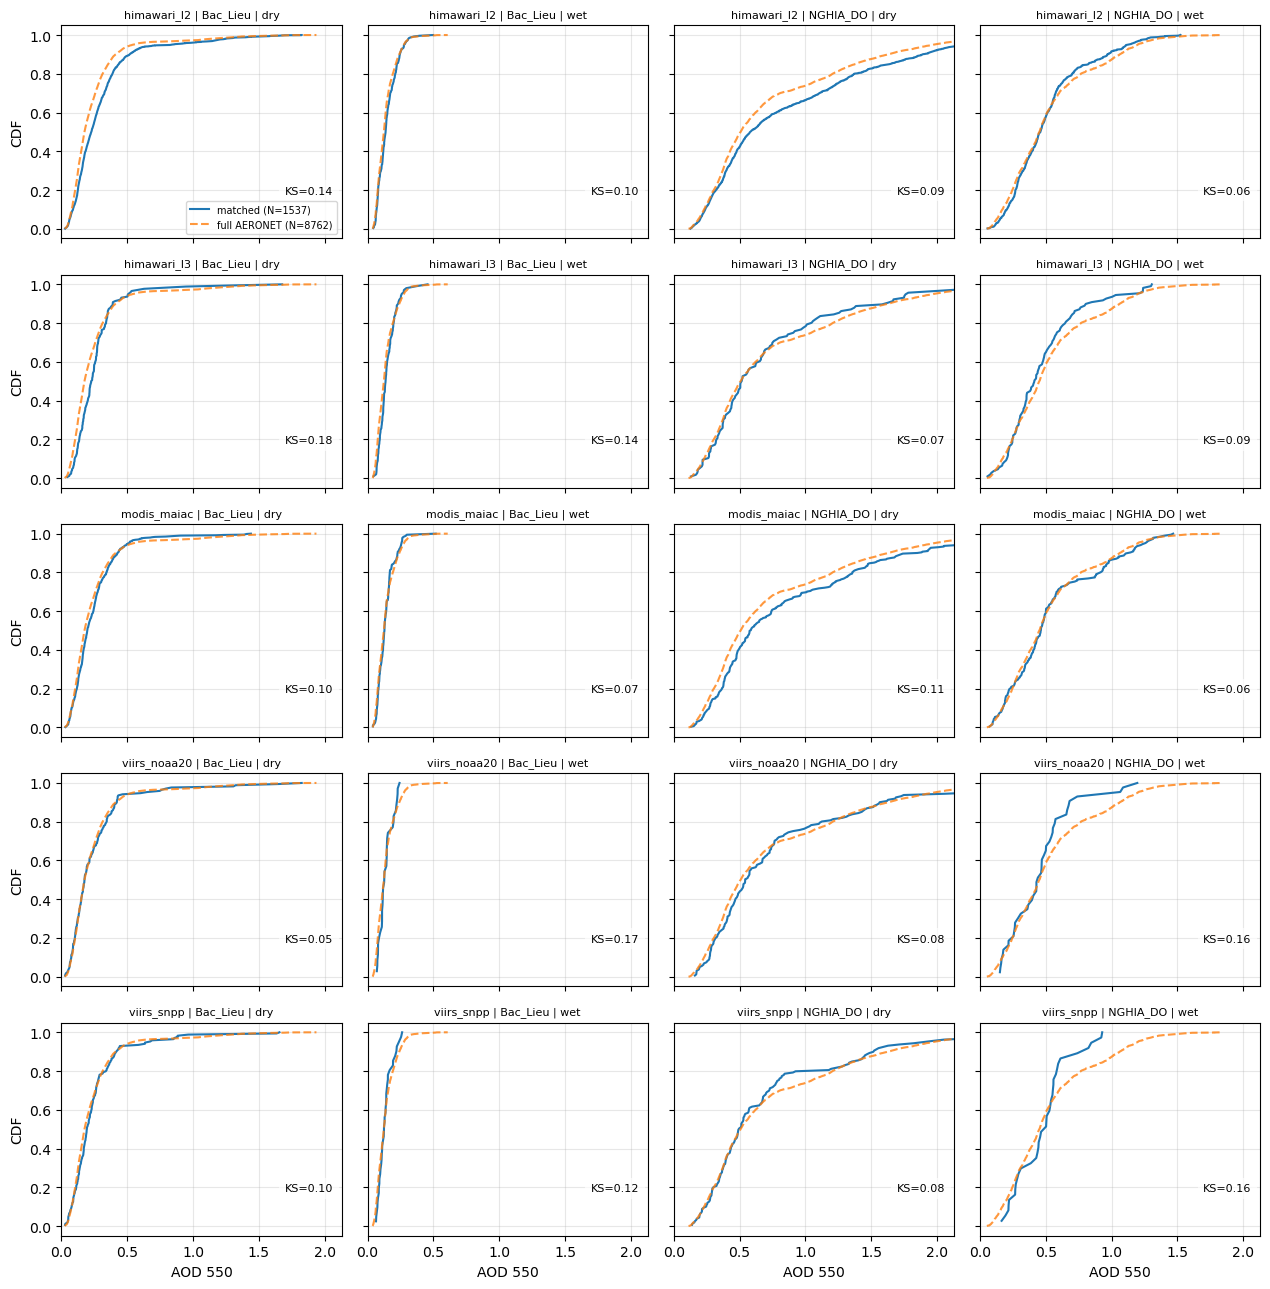

,sensor,site,season,n_matched,n_full,KS,KS_p
0,himawari_l2,Bac_Lieu,dry,1537,8762,0.138969,1.743422e-22
1,himawari_l2,Bac_Lieu,wet,264,2581,0.104932,9.428798e-03
2,himawari_l2,NGHIA_DO,dry,1216,5724,0.092863,5.585677e-08
3,himawari_l2,NGHIA_DO,wet,561,2317,0.057470,9.673853e-02
4,himawari_l3,Bac_Lieu,dry,174,8762,0.181046,2.296193e-05
5,himawari_l3,Bac_Lieu,wet,101,2581,0.139063,4.203784e-02
6,himawari_l3,NGHIA_DO,dry,116,5724,0.065941,6.805443e-01
7,himawari_l3,NGHIA_DO,wet,109,2317,0.087245,3.834495e-01
8,modis_maiac,Bac_Lieu,dry,599,8762,0.096008,5.966535e-05
9,modis_maiac,Bac_Lieu,wet,181,2581,0.068261,3.911815e-01


In [15]:
def ecdf(values: np.ndarray):
    """Return (x, F) of the empirical CDF."""
    x = np.sort(np.asarray(values))
    F = np.arange(1, len(x) + 1) / len(x)
    return x, F

sensors = sorted(pairs['sensor'].unique())
sites   = sorted(pairs['site'].unique())
seasons = ['dry', 'wet']

n_rows = len(sensors)
n_cols = len(sites) * len(seasons)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2 * n_cols, 2.6 * n_rows),
                         sharex=True, sharey=True, squeeze=False)

ks_rows = []
for i, sensor in enumerate(sensors):
    for j, (site, season) in enumerate([(s, ss) for s in sites for ss in seasons]):
        ax = axes[i, j]
        m = pairs[(pairs['sensor'] == sensor) &
                  (pairs['site']   == site)   &
                  (pairs['season'] == season)]['aeronet_aod'].to_numpy()
        f = full_aer[(full_aer['site']   == site) &
                     (full_aer['season'] == season)]['aod_550'].to_numpy()

        if len(m) >= 5 and len(f) >= 5:
            xm, Fm = ecdf(m)
            xf, Ff = ecdf(f)
            ax.plot(xm, Fm, lw=1.5, label=f'matched (N={len(m)})')
            ax.plot(xf, Ff, lw=1.5, ls='--', alpha=0.8, label=f'full AERONET (N={len(f)})')
            ks_stat, ks_p = stats.ks_2samp(m, f)
            ax.text(0.97, 0.2, f'KS={ks_stat:.2f}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        else:
            ax.text(0.5, 0.5, f'N matched={len(m)}\nN full={len(f)}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=8)
            ks_stat, ks_p = np.nan, np.nan

        ks_rows.append({'sensor': sensor, 'site': site, 'season': season,
                        'n_matched': int(len(m)), 'n_full': int(len(f)),
                        'KS': ks_stat, 'KS_p': ks_p})

        ax.set_title(f'{sensor} | {site} | {season}', fontsize=8)
        ax.set_xlim(0, max(1.5, np.nanpercentile(full_aer['aod_550'], 99)))
        ax.grid(alpha=0.3)
        if i == n_rows - 1: ax.set_xlabel('AOD 550')
        if j == 0:          ax.set_ylabel('CDF')
        if i == 0 and j == 0: ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

ks_df = pd.DataFrame(ks_rows)
ks_df

## 2. Range coverage — percentile envelope

Compare the matched-pair 95th and 99th percentiles to the same percentiles in the full
AERONET record at that site/season.  Ratios close to 1.0 = good range coverage; ratios
< 0.85 mean the high-AOD tail is being missed by the satellite matches.

In [5]:
rows = []
for sensor in sensors:
    for site in sites:
        for season in seasons:
            m = pairs[(pairs['sensor'] == sensor) &
                      (pairs['site']   == site)   &
                      (pairs['season'] == season)]['aeronet_aod'].to_numpy()
            f = full_aer[(full_aer['site']   == site) &
                         (full_aer['season'] == season)]['aod_550'].to_numpy()
            if len(m) < 5 or len(f) < 5:
                continue
            p95_m, p99_m = np.percentile(m, [95, 99])
            p95_f, p99_f = np.percentile(f, [95, 99])
            rows.append({
                'sensor': sensor, 'site': site, 'season': season,
                'N_matched': len(m), 'N_full': len(f),
                'p95_matched': p95_m, 'p95_full': p95_f,
                'p95_ratio':   p95_m / p95_f if p95_f > 0 else np.nan,
                'p99_matched': p99_m, 'p99_full': p99_f,
                'p99_ratio':   p99_m / p99_f if p99_f > 0 else np.nan,
                'max_matched': float(m.max()),
                'max_full':    float(f.max()),
            })
pct_df = pd.DataFrame(rows)
pct_df.style.format({
    'p95_matched': '{:.3f}', 'p95_full': '{:.3f}', 'p95_ratio': '{:.2f}',
    'p99_matched': '{:.3f}', 'p99_full': '{:.3f}', 'p99_ratio': '{:.2f}',
    'max_matched': '{:.3f}', 'max_full': '{:.3f}',
}).background_gradient(subset=['p95_ratio', 'p99_ratio'], cmap='RdYlGn', vmin=0.6, vmax=1.1)

,sensor,site,season,N_matched,N_full,p95_matched,p95_full,p95_ratio,p99_matched,p99_full,p99_ratio,max_matched,max_full
0,himawari_l2,Bac_Lieu,dry,1537,8762,0.836,0.542,1.54,1.431,1.329,1.08,1.824,1.936
1,himawari_l2,Bac_Lieu,wet,264,2581,0.278,0.275,1.01,0.338,0.349,0.97,0.497,0.608
2,himawari_l2,NGHIA_DO,dry,1216,5724,2.251,1.970,1.14,2.568,2.435,1.05,3.284,3.284
3,himawari_l2,NGHIA_DO,wet,561,2317,1.124,1.199,0.94,1.358,1.471,0.92,1.523,1.836
4,himawari_l3,Bac_Lieu,dry,174,8762,0.508,0.542,0.94,1.037,1.329,0.78,1.676,1.936
5,himawari_l3,Bac_Lieu,wet,101,2581,0.259,0.275,0.94,0.368,0.349,1.06,0.456,0.608
6,himawari_l3,NGHIA_DO,dry,116,5724,1.765,1.970,0.90,2.300,2.435,0.94,2.464,3.284
7,himawari_l3,NGHIA_DO,wet,109,2317,1.141,1.199,0.95,1.294,1.471,0.88,1.305,1.836
8,modis_maiac,Bac_Lieu,dry,599,8762,0.507,0.542,0.94,0.910,1.329,0.68,1.439,1.936
9,modis_maiac,Bac_Lieu,wet,181,2581,0.258,0.275,0.94,0.292,0.349,0.84,0.517,0.608


## 3. Density coverage — pairs per AERONET decile

Bin matched AERONET AOD into 10 equal-quantile bins (deciles computed from the **full**
AERONET record at that stratum so the bins are interpretable on the production grid).
Each bin should have N ≥ 10, ideally ≥ 20.  Low counts in the top decile → the CDF
transfer is being fit by a handful of points in the part of the distribution that
matters most for pollution events.

In [6]:
decile_rows = []
for sensor in sensors:
    for site in sites:
        for season in seasons:
            m = pairs[(pairs['sensor'] == sensor) &
                      (pairs['site']   == site)   &
                      (pairs['season'] == season)]['aeronet_aod'].to_numpy()
            f = full_aer[(full_aer['site']   == site) &
                         (full_aer['season'] == season)]['aod_550'].to_numpy()
            if len(m) < 5 or len(f) < 10:
                continue
            edges = np.percentile(f, np.linspace(0, 100, 11))
            edges[0]  -= 1e-6
            edges[-1] += 1e-6
            counts, _ = np.histogram(m, bins=edges)
            rec = {'sensor': sensor, 'site': site, 'season': season, 'N_total': len(m)}
            for k, c in enumerate(counts, start=1):
                rec[f'D{k}'] = int(c)
            rec['deciles_ge_5']  = int((counts >= 5).sum())
            rec['deciles_ge_10'] = int((counts >= 10).sum())
            decile_rows.append(rec)
dec_df = pd.DataFrame(decile_rows)
dec_cols = [c for c in dec_df.columns if c.startswith('D')]
dec_df.style.format({c: '{:d}' for c in dec_cols + ['N_total', 'deciles_ge_5', 'deciles_ge_10']}) \
            .background_gradient(subset=dec_cols, cmap='YlGn', vmin=0, vmax=30)

,sensor,site,season,N_total,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,deciles_ge_5,deciles_ge_10
0,himawari_l2,Bac_Lieu,dry,1537,127,77,119,118,142,136,157,169,232,260,10,10
1,himawari_l2,Bac_Lieu,wet,264,18,24,27,18,25,21,35,29,35,32,10,10
2,himawari_l2,NGHIA_DO,dry,1216,105,123,77,101,119,106,111,149,140,185,10,10
3,himawari_l2,NGHIA_DO,wet,561,36,48,70,61,61,57,79,56,51,42,10,10
4,himawari_l3,Bac_Lieu,dry,174,6,12,12,12,16,16,30,29,26,15,10,9
5,himawari_l3,Bac_Lieu,wet,101,1,7,11,8,14,10,13,13,16,8,9,6
6,himawari_l3,NGHIA_DO,dry,116,11,8,13,8,17,10,17,13,8,11,10,7
7,himawari_l3,NGHIA_DO,wet,109,7,14,14,14,13,10,10,14,7,6,10,7
8,modis_maiac,Bac_Lieu,dry,599,60,36,45,48,66,71,63,70,72,68,10,10
9,modis_maiac,Bac_Lieu,wet,181,7,18,24,14,19,23,20,27,14,15,10,9


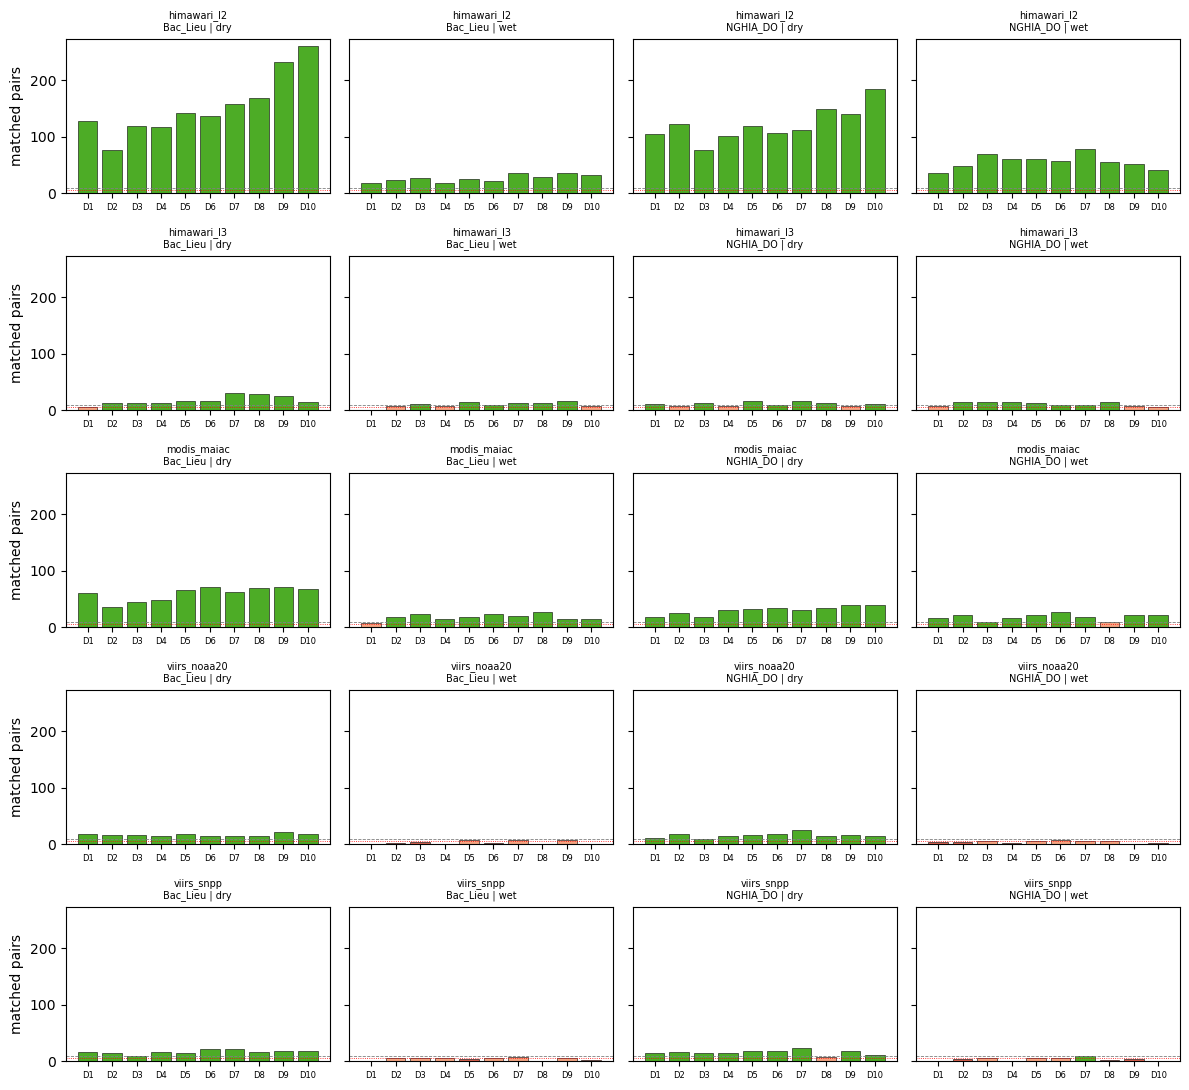

In [7]:
# Bar plot of decile counts — one row per sensor, one column per site×season
if not dec_df.empty:
    fig, axes = plt.subplots(len(sensors), len(sites) * len(seasons),
                             figsize=(3.0 * len(sites) * len(seasons), 2.2 * len(sensors)),
                             sharey=True, squeeze=False)
    for i, sensor in enumerate(sensors):
        for j, (site, season) in enumerate([(s, ss) for s in sites for ss in seasons]):
            ax  = axes[i, j]
            sub = dec_df[(dec_df['sensor'] == sensor) &
                         (dec_df['site']   == site)   &
                         (dec_df['season'] == season)]
            if sub.empty:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center')
            else:
                counts = sub.iloc[0][dec_cols].astype(int).to_numpy()
                colors = ['#d6604d' if c < 5 else ('#f4a582' if c < 10 else '#4dac26')
                          for c in counts]
                ax.bar(range(1, 11), counts, color=colors, edgecolor='black', linewidth=0.4)
                ax.axhline(10, color='gray', ls='--', lw=0.6)
                ax.axhline(5,  color='red',  ls=':', lw=0.6)
            ax.set_title(f'{sensor}\n{site} | {season}', fontsize=7)
            ax.set_xticks(range(1, 11))
            ax.set_xticklabels([f'D{k}' for k in range(1, 11)], fontsize=6)
            if j == 0: ax.set_ylabel('matched pairs')
    plt.tight_layout()
    plt.show()

## 4. Tail diagnostic — scatter with CDF-transfer overlay

For each stratum, plot satellite vs AERONET AOD pairs and overlay the empirical CDF
transfer mapping (the function that bias correction would actually apply).  Points in
the top decile of AERONET AOD are highlighted; if the highlighted set is < ~5 points
lying in a near-vertical line, the CDF mapping in that range is being defined by noise.

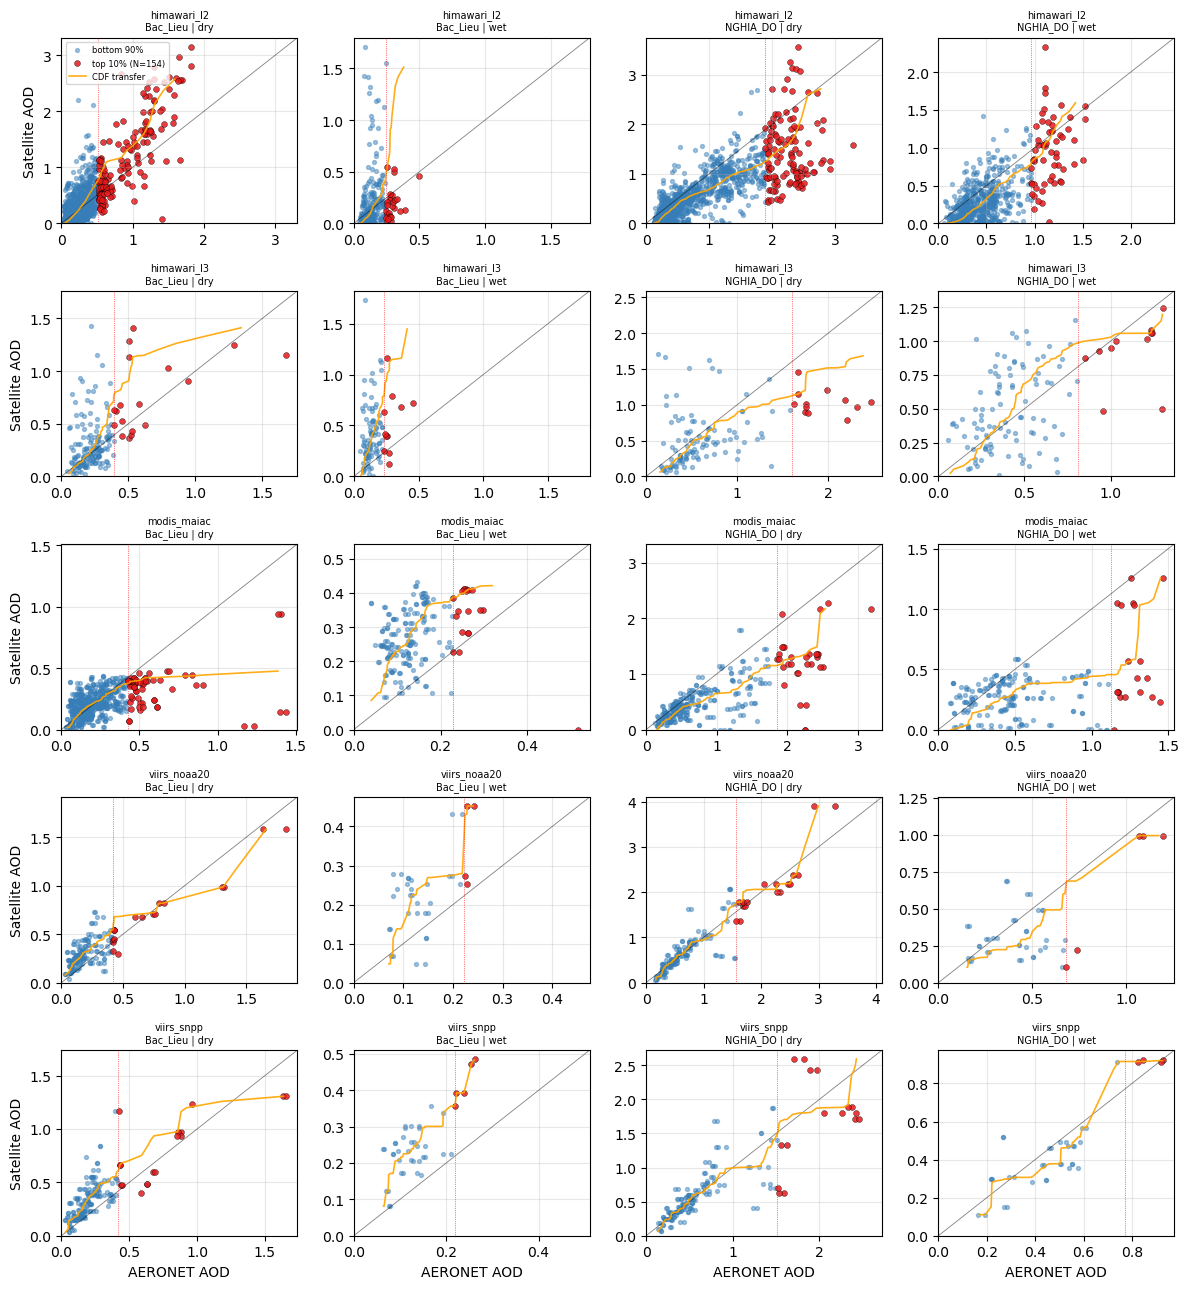

In [8]:
from config import CDF_N_QUANTILES

def cdf_transfer(sat: np.ndarray, aer: np.ndarray, q: int = CDF_N_QUANTILES):
    """Return (sat_q, aer_q): quantile pairs defining the CDF transfer satellite→AERONET."""
    probs = np.linspace(0.005, 0.995, q)
    return np.quantile(sat, probs), np.quantile(aer, probs)

fig, axes = plt.subplots(len(sensors), len(sites) * len(seasons),
                         figsize=(3.0 * len(sites) * len(seasons), 2.6 * len(sensors)),
                         squeeze=False)
for i, sensor in enumerate(sensors):
    for j, (site, season) in enumerate([(s, ss) for s in sites for ss in seasons]):
        ax  = axes[i, j]
        sub = pairs[(pairs['sensor'] == sensor) &
                    (pairs['site']   == site)   &
                    (pairs['season'] == season)]
        if len(sub) < 5:
            ax.text(0.5, 0.5, f'N={len(sub)}', transform=ax.transAxes,
                    ha='center', va='center')
        else:
            aer = sub['aeronet_aod'].to_numpy()
            sat = sub['satellite_aod'].to_numpy()
            p90 = np.percentile(aer, 90)
            top = aer >= p90
            ax.scatter(aer[~top], sat[~top], s=8, alpha=0.45, color='#377eb8',
                       label='bottom 90%')
            ax.scatter(aer[top],  sat[top],  s=18, alpha=0.85, color='#e41a1c',
                       edgecolor='black', linewidth=0.3, label=f'top 10% (N={int(top.sum())})')
            lim = max(float(np.max(aer)), float(np.max(sat))) * 1.05
            ax.plot([0, lim], [0, lim], 'k-', lw=0.6, alpha=0.5)
            try:
                sq, aq = cdf_transfer(sat, aer)
                ax.plot(aq, sq, color='orange', lw=1.2, alpha=0.9, label='CDF transfer')
            except Exception:
                pass
            ax.set_xlim(0, lim);  ax.set_ylim(0, lim)
            ax.axvline(p90, color='red', ls=':', lw=0.5)
            if i == 0 and j == 0:
                ax.legend(fontsize=6, loc='upper left')
        ax.set_title(f'{sensor}\n{site} | {season}', fontsize=7)
        if i == len(sensors) - 1: ax.set_xlabel('AERONET AOD')
        if j == 0:                ax.set_ylabel('Satellite AOD')
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Acceptance summary

Per (sensor × site × season) stratum, evaluate each check against its threshold.  A
stratum that fails any check should not be trusted for downstream CDF-based bias
correction without either pooling pairs across seasons or reverting to a linear fit.

| Check                            | Threshold |
|----------------------------------|-----------|
| N total pairs                    | ≥ 100    |
| KS(matched, full-AERONET)        | < 0.15    |
| Matched 95th pct / Full 95th pct | > 0.85    |
| Deciles with N ≥ 5               | ≥ 7 of 10 |
| Pair-level Pearson R             | ≥ 0.30    |

In [9]:
THRESHOLDS = {
    'N':         100,
    'KS_max':    0.15,
    'p95_ratio': 0.85,
    'deciles':   7,
    'R_min':     0.30,
}

rows = []
for sensor in sensors:
    for site in sites:
        for season in seasons:
            sub = pairs[(pairs['sensor'] == sensor) &
                        (pairs['site']   == site)   &
                        (pairs['season'] == season)]
            f   = full_aer[(full_aer['site']   == site) &
                           (full_aer['season'] == season)]['aod_550'].to_numpy()
            n = len(sub)
            row = {'sensor': sensor, 'site': site, 'season': season, 'N': n}
            if n < 5 or len(f) < 5:
                row.update({'KS': np.nan, 'p95_ratio': np.nan,
                            'deciles_ge_5': np.nan, 'R': np.nan,
                            'pass_N': False, 'pass_KS': False, 'pass_p95': False,
                            'pass_dec': False, 'pass_R': False, 'pass_all': False})
                rows.append(row); continue

            m = sub['aeronet_aod'].to_numpy()
            s = sub['satellite_aod'].to_numpy()
            ks, _ = stats.ks_2samp(m, f)
            p95_m = np.percentile(m, 95)
            p95_f = np.percentile(f, 95)
            p95_r = p95_m / p95_f if p95_f > 0 else np.nan
            edges = np.percentile(f, np.linspace(0, 100, 11))
            edges[0]  -= 1e-6
            edges[-1] += 1e-6
            counts, _ = np.histogram(m, bins=edges)
            dec_ok = int((counts >= 5).sum())
            r_val, _ = stats.pearsonr(s, m) if len(s) >= 3 else (np.nan, np.nan)

            row['KS']           = ks
            row['p95_ratio']    = p95_r
            row['deciles_ge_5'] = dec_ok
            row['R']            = r_val
            row['pass_N']   = n        >= THRESHOLDS['N']
            row['pass_KS']  = ks       <  THRESHOLDS['KS_max']
            row['pass_p95'] = p95_r    >  THRESHOLDS['p95_ratio']
            row['pass_dec'] = dec_ok   >= THRESHOLDS['deciles']
            row['pass_R']   = (r_val   >= THRESHOLDS['R_min']) if pd.notna(r_val) else False
            row['pass_all'] = bool(row['pass_N'] and row['pass_KS']
                                   and row['pass_p95'] and row['pass_dec']
                                   and row['pass_R'])
            rows.append(row)

summary = pd.DataFrame(rows)
pass_cols = ['pass_N', 'pass_KS', 'pass_p95', 'pass_dec', 'pass_R', 'pass_all']

def _hl(v):
    if isinstance(v, (bool, np.bool_)):
        return 'background-color: #c7e9c0' if v else 'background-color: #fcae91'
    return ''

summary.style.format({
    'KS': '{:.3f}', 'p95_ratio': '{:.2f}', 'R': '{:.2f}',
    'N': '{:d}', 'deciles_ge_5': '{:.0f}',
}, na_rep='—').applymap(_hl, subset=pass_cols)

/tmp/ipykernel_291390/1608424108.py:65: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  }, na_rep='—').applymap(_hl, subset=pass_cols)


,sensor,site,season,N,KS,p95_ratio,deciles_ge_5,R,pass_N,pass_KS,pass_p95,pass_dec,pass_R,pass_all
0,himawari_l2,Bac_Lieu,dry,1537,0.139,1.54,10,0.83,True,True,True,True,True,True
1,himawari_l2,Bac_Lieu,wet,264,0.105,1.01,10,0.15,True,True,True,True,False,False
2,himawari_l2,NGHIA_DO,dry,1216,0.093,1.14,10,0.79,True,True,True,True,True,True
3,himawari_l2,NGHIA_DO,wet,561,0.057,0.94,10,0.67,True,True,True,True,True,True
4,himawari_l3,Bac_Lieu,dry,174,0.181,0.94,10,0.52,True,False,True,True,True,False
5,himawari_l3,Bac_Lieu,wet,101,0.139,0.94,9,0.22,True,True,True,True,False,False
6,himawari_l3,NGHIA_DO,dry,116,0.066,0.90,10,0.45,True,True,True,True,True,True
7,himawari_l3,NGHIA_DO,wet,109,0.087,0.95,10,0.53,True,True,True,True,True,True
8,modis_maiac,Bac_Lieu,dry,599,0.096,0.94,10,0.48,True,True,True,True,True,True
9,modis_maiac,Bac_Lieu,wet,181,0.068,0.94,10,0.23,True,True,True,True,False,False


In [10]:
# Quick textual roll-up
if not summary.empty:
    total = len(summary)
    pas   = int(summary['pass_all'].sum())
    print(f'Strata passing every check: {pas} / {total}')
    print('\nFails by check:')
    for col in ['pass_N', 'pass_KS', 'pass_p95', 'pass_dec', 'pass_R']:
        fails = summary[~summary[col]]
        print(f'  {col:10s} : {len(fails)} strata fail')
    print('\nFailing strata:')
    bad = summary[~summary['pass_all']][
        ['sensor', 'site', 'season', 'N', 'KS', 'p95_ratio', 'deciles_ge_5', 'R'] + pass_cols
    ]
    print(bad.to_string(index=False))

Strata passing every check: 12 / 20

Fails by check:
  pass_N     : 4 strata fail
  pass_KS    : 4 strata fail
  pass_p95   : 2 strata fail
  pass_dec   : 4 strata fail
  pass_R     : 3 strata fail

Failing strata:
      sensor     site season   N       KS  p95_ratio  deciles_ge_5        R  pass_N  pass_KS  pass_p95  pass_dec  pass_R  pass_all
 himawari_l2 Bac_Lieu    wet 264 0.104932   1.011012            10 0.147259    True     True      True      True   False     False
 himawari_l3 Bac_Lieu    dry 174 0.181046   0.938340            10 0.523678    True    False      True      True    True     False
 himawari_l3 Bac_Lieu    wet 101 0.139063   0.942796             9 0.221023    True     True      True      True   False     False
 modis_maiac Bac_Lieu    wet 181 0.068261   0.937331            10 0.230401    True     True      True      True   False     False
viirs_noaa20 Bac_Lieu    wet  35 0.174373   0.829888             3 0.590391   False    False     False     False    True     False

## 6. Pre-correction acid test — sensor × region × season scatter

The acid test for whether the inputs are *good enough* to bias-correct at all.  Pool
matched pairs across sites within each region (sites in the same region share regional
aerosol behaviour) and scatter raw **satellite vs AERONET** AOD per
`(sensor × region × season)` stratum.  We are looking for:

- **A visible trend.**  Pearson R ≥ 0.30 (acceptable), ≥ 0.50 (good).  R < 0.30 means
  the satellite retrieval has no usable signal in that stratum and no CDF rescaling
  will fix it.
- **A wide range on both axes.**  Points must not be clustered at one AOD level.
  Use the matched IQR / 90th-percentile span as a proxy for dynamic range.
- **Enough points.**  N ≥ 100 ideally, ≥ 50 minimum.  Below 50, R is dominated by
  sampling noise.
- **No obvious QA leakage.**  Flag pairs where the satellite reports a heavy plume
  (`satellite_aod ≥ 1.5`) while AERONET reports clean air (`aeronet_aod ≤ 0.3`), or
  vice versa — these are the "AOD = 5 vs 0.2" cases that mean a cloud / surface
  artefact slipped past QA.

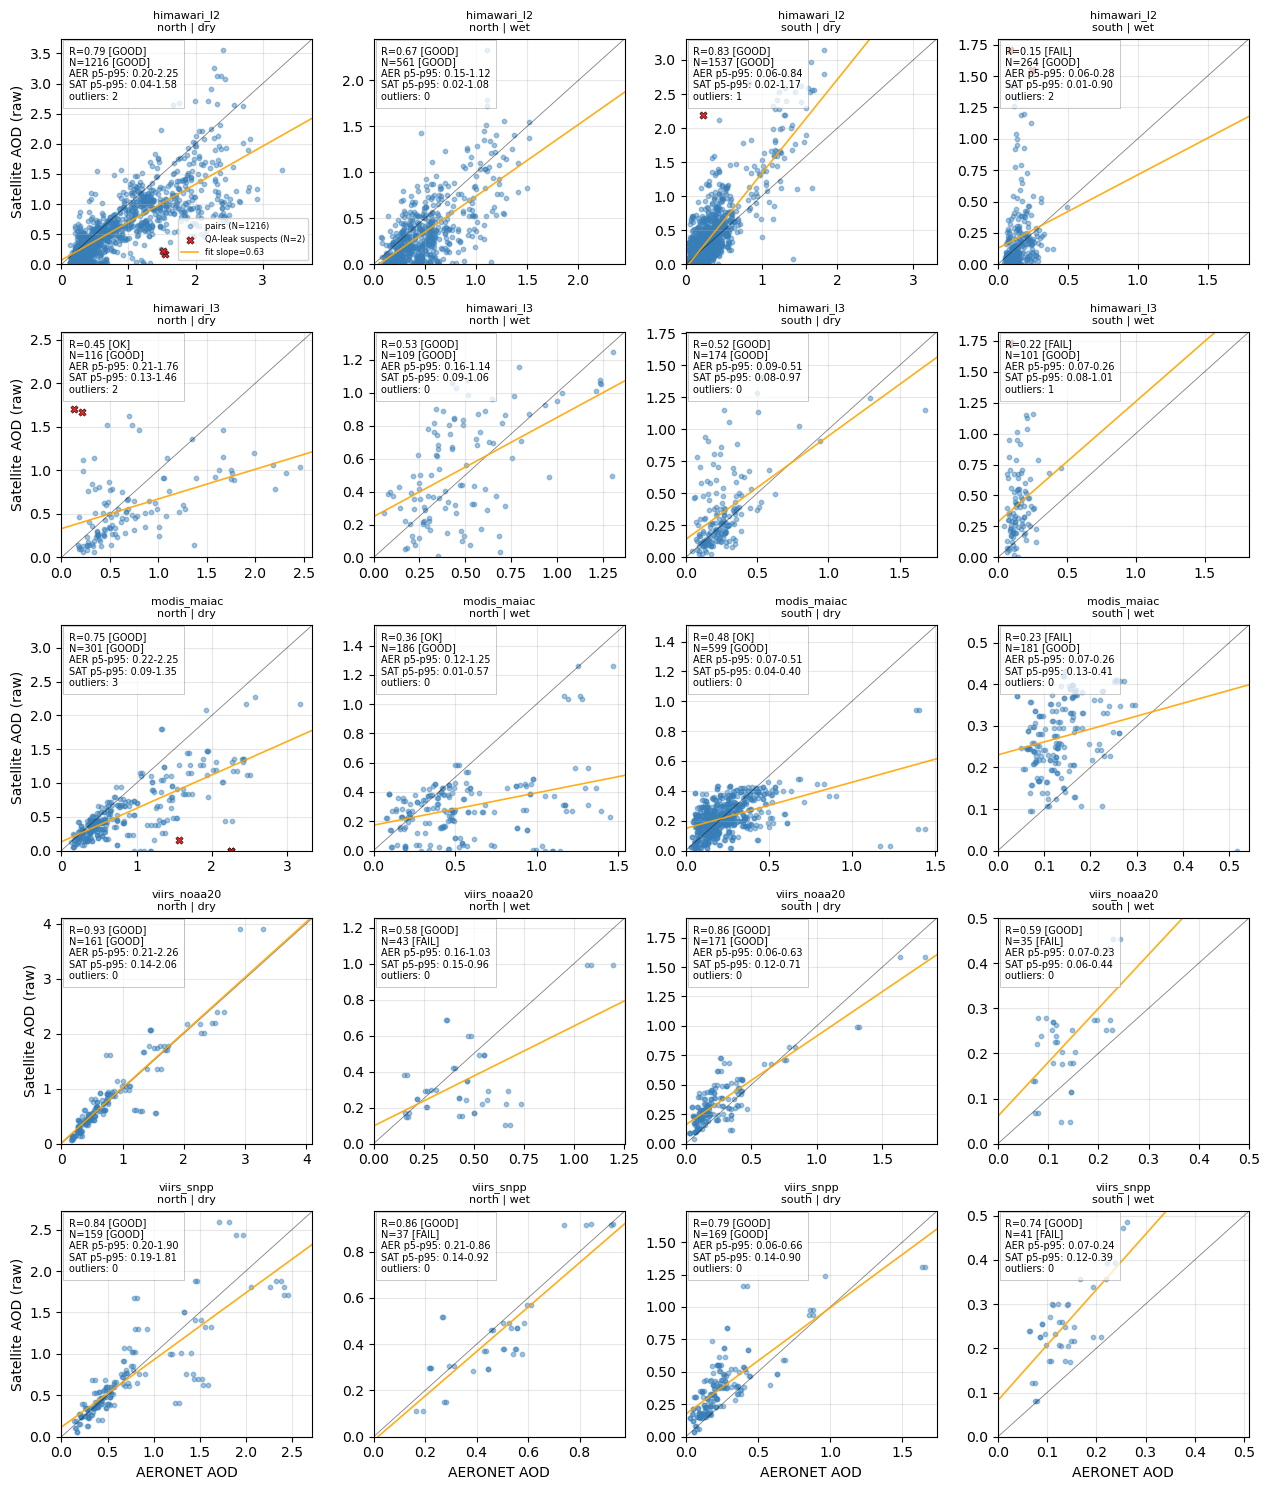

,sensor,region,season,N,R,aer_p5,aer_p95,sat_p5,sat_p95,n_outliers,outlier_frac
0,himawari_l2,north,dry,1216,0.790096,0.200957,2.250577,0.035862,1.579783,2,0.001645
1,himawari_l2,north,wet,561,0.668600,0.153469,1.123649,0.017596,1.082372,0,0.000000
2,himawari_l2,south,dry,1537,0.833801,0.062952,0.835973,0.019570,1.165901,1,0.000651
3,himawari_l2,south,wet,264,0.147259,0.061975,0.277898,0.006487,0.901003,2,0.007576
4,himawari_l3,north,dry,116,0.447903,0.209265,1.764814,0.125804,1.458608,2,0.017241
5,himawari_l3,north,wet,109,0.530454,0.155171,1.140759,0.087924,1.057107,0,0.000000
6,himawari_l3,south,dry,174,0.523678,0.089380,0.508444,0.083359,0.968270,0,0.000000
7,himawari_l3,south,wet,101,0.221023,0.069120,0.259147,0.078485,1.014772,1,0.009901
8,modis_maiac,north,dry,301,0.748205,0.220776,2.252178,0.094727,1.352765,3,0.009967
9,modis_maiac,north,wet,186,0.363039,0.119946,1.251727,0.011583,0.565500,0,0.000000


In [11]:
ACID = {
    'N_ideal':       100,
    'N_min':         50,
    'R_ideal':       0.50,
    'R_min':         0.30,
    'sat_high':      1.5,   # satellite AOD considered "plume"
    'aer_low':       0.3,   # AERONET AOD considered "clean"
    'sat_clean':     0.3,
    'aer_high':      1.5,
}

regions = sorted(pairs['region'].unique())

n_rows = len(sensors)
n_cols = len(regions) * len(seasons)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2 * n_cols, 3.0 * n_rows), squeeze=False)

acid_rows = []
for i, sensor in enumerate(sensors):
    for j, (region, season) in enumerate([(r, ss) for r in regions for ss in seasons]):
        ax  = axes[i, j]
        sub = pairs[(pairs['sensor'] == sensor) &
                    (pairs['region'] == region) &
                    (pairs['season'] == season)]
        n   = len(sub)
        row = {'sensor': sensor, 'region': region, 'season': season, 'N': n}

        if n < 3:
            ax.text(0.5, 0.5, f'N={n}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=10)
            row.update({'R': np.nan, 'aer_p5': np.nan, 'aer_p95': np.nan,
                        'sat_p5': np.nan, 'sat_p95': np.nan,
                        'n_outliers': 0, 'outlier_frac': np.nan})
            acid_rows.append(row)
            ax.set_title(f'{sensor}\n{region} | {season}', fontsize=8)
            continue

        aer = sub['aeronet_aod'].to_numpy()
        sat = sub['satellite_aod'].to_numpy()

        # Outlier flag: heavy satellite vs clean AERONET, or vice-versa
        outlier = (((sat >= ACID['sat_high']) & (aer <= ACID['aer_low'])) |
                   ((aer >= ACID['aer_high']) & (sat <= ACID['sat_clean'])))
        n_out   = int(outlier.sum())

        # Pearson R on the (raw) pairs
        r_val, _ = stats.pearsonr(sat, aer) if n >= 3 else (np.nan, np.nan)

        # Dynamic range proxies
        aer_p5,  aer_p95 = np.percentile(aer, [5, 95])
        sat_p5,  sat_p95 = np.percentile(sat, [5, 95])

        # Scatter
        ax.scatter(aer[~outlier], sat[~outlier], s=10, alpha=0.45,
                   color='#377eb8', label=f'pairs (N={n})')
        if n_out:
            ax.scatter(aer[outlier], sat[outlier], s=28, alpha=0.95,
                       color='#e41a1c', edgecolor='black', linewidth=0.4,
                       marker='X', label=f'QA-leak suspects (N={n_out})')

        lim = max(float(aer.max()), float(sat.max())) * 1.05
        lim = max(lim, 0.5)
        ax.plot([0, lim], [0, lim], 'k-', lw=0.6, alpha=0.5)

        # Linear fit overlay (raw, pre-correction)
        if n >= 3:
            slope, intercept = np.polyfit(aer, sat, 1)
            xs = np.array([0, lim])
            ax.plot(xs, slope * xs + intercept, color='orange', lw=1.2,
                    alpha=0.9, label=f'fit slope={slope:.2f}')

        # Annotations
        flag_R = ('GOOD' if r_val >= ACID['R_ideal'] else
                  ('OK'   if r_val >= ACID['R_min']   else 'FAIL'))
        flag_N = ('GOOD' if n     >= ACID['N_ideal'] else
                  ('OK'   if n     >= ACID['N_min']   else 'FAIL'))
        txt = (f'R={r_val:.2f} [{flag_R}]\n'
               f'N={n} [{flag_N}]\n'
               f'AER p5-p95: {aer_p5:.2f}-{aer_p95:.2f}\n'
               f'SAT p5-p95: {sat_p5:.2f}-{sat_p95:.2f}\n'
               f'outliers: {n_out}')
        ax.text(0.03, 0.97, txt, transform=ax.transAxes,
                ha='left', va='top', fontsize=7,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='gray', lw=0.4))

        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.grid(alpha=0.3)
        ax.set_title(f'{sensor}\n{region} | {season}', fontsize=8)
        if i == n_rows - 1: ax.set_xlabel('AERONET AOD')
        if j == 0:          ax.set_ylabel('Satellite AOD (raw)')
        if i == 0 and j == 0:
            ax.legend(fontsize=6, loc='lower right')

        row.update({
            'R': r_val,
            'aer_p5': aer_p5, 'aer_p95': aer_p95,
            'sat_p5': sat_p5, 'sat_p95': sat_p95,
            'n_outliers': n_out,
            'outlier_frac': n_out / n,
        })
        acid_rows.append(row)

plt.tight_layout()
plt.show()

acid_df = pd.DataFrame(acid_rows)
acid_df

In [12]:
# Acid-test verdict table (sensor × region × season)
verdict = acid_df.copy()

def _grade_N(n):
    if pd.isna(n):              return '—'
    if n >= ACID['N_ideal']:    return 'GOOD'
    if n >= ACID['N_min']:      return 'OK'
    return 'FAIL'

def _grade_R(r):
    if pd.isna(r):              return '—'
    if r >= ACID['R_ideal']:    return 'GOOD'
    if r >= ACID['R_min']:      return 'OK'
    return 'FAIL'

def _grade_range(p5, p95):
    if pd.isna(p5) or pd.isna(p95):  return '—'
    return 'OK' if (p95 - p5) >= 0.10 else 'FAIL'

def _grade_outliers(frac):
    if pd.isna(frac):           return '—'
    return 'OK' if frac <= 0.02 else 'FAIL'

verdict['grade_N']        = verdict['N'].apply(_grade_N)
verdict['grade_R']        = verdict['R'].apply(_grade_R)
verdict['grade_aer_rng']  = verdict.apply(lambda r: _grade_range(r['aer_p5'], r['aer_p95']), axis=1)
verdict['grade_sat_rng']  = verdict.apply(lambda r: _grade_range(r['sat_p5'], r['sat_p95']), axis=1)
verdict['grade_outliers'] = verdict['outlier_frac'].apply(_grade_outliers)
verdict['acid_pass']      = (verdict[['grade_N', 'grade_R',
                                      'grade_aer_rng', 'grade_sat_rng',
                                      'grade_outliers']]
                             .isin(['GOOD', 'OK']).all(axis=1))

cols = ['sensor', 'region', 'season', 'N', 'R',
        'aer_p5', 'aer_p95', 'sat_p5', 'sat_p95',
        'n_outliers', 'outlier_frac',
        'grade_N', 'grade_R', 'grade_aer_rng', 'grade_sat_rng',
        'grade_outliers', 'acid_pass']

def _hl_grade(v):
    if v == 'GOOD': return 'background-color: #c7e9c0'
    if v == 'OK':   return 'background-color: #fff7bc'
    if v == 'FAIL': return 'background-color: #fcae91'
    if isinstance(v, (bool, np.bool_)):
        return 'background-color: #c7e9c0' if v else 'background-color: #fcae91'
    return ''

verdict[cols].style.format({
    'R': '{:.2f}',
    'aer_p5': '{:.2f}', 'aer_p95': '{:.2f}',
    'sat_p5': '{:.2f}', 'sat_p95': '{:.2f}',
    'outlier_frac': '{:.1%}',
    'N': '{:d}', 'n_outliers': '{:d}',
}, na_rep='—').map(_hl_grade,
                   subset=['grade_N', 'grade_R', 'grade_aer_rng',
                           'grade_sat_rng', 'grade_outliers', 'acid_pass'])

,sensor,region,season,N,R,aer_p5,aer_p95,sat_p5,sat_p95,n_outliers,outlier_frac,grade_N,grade_R,grade_aer_rng,grade_sat_rng,grade_outliers,acid_pass
0,himawari_l2,north,dry,1216,0.79,0.20,2.25,0.04,1.58,2,0.2%,GOOD,GOOD,OK,OK,OK,True
1,himawari_l2,north,wet,561,0.67,0.15,1.12,0.02,1.08,0,0.0%,GOOD,GOOD,OK,OK,OK,True
2,himawari_l2,south,dry,1537,0.83,0.06,0.84,0.02,1.17,1,0.1%,GOOD,GOOD,OK,OK,OK,True
3,himawari_l2,south,wet,264,0.15,0.06,0.28,0.01,0.90,2,0.8%,GOOD,FAIL,OK,OK,OK,False
4,himawari_l3,north,dry,116,0.45,0.21,1.76,0.13,1.46,2,1.7%,GOOD,OK,OK,OK,OK,True
5,himawari_l3,north,wet,109,0.53,0.16,1.14,0.09,1.06,0,0.0%,GOOD,GOOD,OK,OK,OK,True
6,himawari_l3,south,dry,174,0.52,0.09,0.51,0.08,0.97,0,0.0%,GOOD,GOOD,OK,OK,OK,True
7,himawari_l3,south,wet,101,0.22,0.07,0.26,0.08,1.01,1,1.0%,GOOD,FAIL,OK,OK,OK,False
8,modis_maiac,north,dry,301,0.75,0.22,2.25,0.09,1.35,3,1.0%,GOOD,GOOD,OK,OK,OK,True
9,modis_maiac,north,wet,186,0.36,0.12,1.25,0.01,0.57,0,0.0%,GOOD,OK,OK,OK,OK,True
